In [1]:
import sys
sys.path.append("../src")

In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import readers as readers

DATA_DIR = "../assets/data"
dfs: dict[str, pd.DataFrame] = readers.load_csv(DATA_DIR)

# Schema

![img](../assets/schemas/er-trans.png)

# 

# Merges

In [3]:
order_w_geo = dfs["orders"].rename(columns=lambda i: f"orders.{i}").merge(
    dfs["geography"].rename(columns=lambda i: f"geography.{i}"),
    "left",
    left_on="orders.zip",
    right_on="geography.zip"
)
items_w_prods = dfs["order_items"].rename(columns=lambda i: f"order_items.{i}").merge(
    dfs["products"].rename(columns=lambda i: f"products.{i}"),
    "left",
    left_on="order_items.product_id",
    right_on="products.product_id"
)
customer_w_geo = dfs["customers"].rename(columns=lambda i: f"customers.{i}").merge(
    dfs["geography"].rename(columns=lambda i: f"cus_geo.{i}"),
    "left",
    left_on="customers.zip",
    right_on="cus_geo.zip"
)

In [4]:
full_orders = order_w_geo.merge(
    customer_w_geo, "left",
    left_on="orders.customer_id",
    right_on="customers.customer_id"
)

full_order_items = items_w_prods.merge(
    full_orders, "left",
    left_on="order_items.order_id",
    right_on="orders.order_id"
)

full_returns = dfs["returns"].rename(columns=lambda i: f"returns.{i}").merge(
    full_order_items, "left",
    left_on="returns.order_id",
    right_on="orders.order_id"
)

full_reviews = dfs["reviews"].rename(columns=lambda i: f"reviews.{i}").merge(
    full_order_items, "left",
    left_on="reviews.order_id",
    right_on="orders.order_id"
)

full_order_items["sales_value"] = full_order_items["order_items.quantity"] * full_order_items["order_items.unit_price"] 

In [5]:
# full_shipments = dfs["shipments"].rename(lambda i: f"shipments.{i}").merge(
#     full_order_items
# )

# Promotions

In [5]:
promotions = dfs["promotions"].copy()

promotions["norm_start"] = pd.to_datetime({
    "year": 2000,
    "month": promotions["start_date"].dt.month,
    "day": promotions["start_date"].dt.day
})
promotions["norm_end"] = pd.to_datetime({
    "year": 2000,
    "month": promotions["end_date"].dt.month,
    "day": promotions["end_date"].dt.day
})

promotions["promo_group"] = promotions["promo_name"].str.slice(stop=-5)
promotions.groupby("promo_group").agg(
    start_dates=("norm_start", "unique"),
    end_dates=("norm_end", "unique"),
)

,start_dates,end_dates
promo_group,,
Fall Launch,"[2000-08-30 00:00:00, 2000-08-31 00:00:00]","[2000-10-02 00:00:00, 2000-10-01 00:00:00]"
Mid-Year Sale,[2000-06-23 00:00:00],[2000-07-22 00:00:00]
Rural Special,"[2000-01-31 00:00:00, 2000-01-30 00:00:00]",[2000-03-01 00:00:00]
Spring Sale,[2000-03-18 00:00:00],[2000-04-17 00:00:00]
Urban Blowout,[2000-07-30 00:00:00],[2000-09-02 00:00:00]
Year-End Sale,"[2000-11-18 00:00:00, 2000-11-19 00:00:00]","[2000-01-02 00:00:00, 2000-01-01 00:00:00, 200..."


In [6]:
def get_sales_period(promo_name, year):
    year = f"{year:0>4}"
    if promo_name == "Spring Sale":
        return pd.to_datetime(f"{year}-03-18"), pd.to_datetime(f"{year}-04-17")
    elif promo_name == "Mid-Year Sale":
        return pd.to_datetime(f"{year}-06-23"), pd.to_datetime(f"{year}-07-22")
    elif promo_name == "Fall Launch":
        is_prev_leap_year = pd.to_datetime(f"{int(year):0>4}-01-01")
        return (
            pd.to_datetime(f"{year}-08-30"),
            pd.to_datetime(f"{year}-10-02") if is_prev_leap_year else pd.to_datetime(f"{year}-10-01")
        )
    elif promo_name == "Year-End Sale":
        start = pd.to_datetime(f"{year}-11-18")
        return start, start + pd.Timedelta(days=45)
    elif promo_name == "Urban Blowout":
        if int(year) % 2:
            raise ValueError(f"{promo_name} only supported in odd year")
        return pd.to_datetime(f"{year}-07-30"), pd.to_datetime(f"{year}-09-02")
    elif promo_name == "Rural Special":
        if int(year) % 2:
            raise ValueError(f"{promo_name} only supported in odd year")
        return pd.to_datetime(f"{year}-01-30"), pd.to_datetime(f"{year}-03-01")
    else:
        raise ValueError(f"Unknown promotion {promo_name}")

In [7]:
full_order_items = full_order_items.join(
    promotions.set_index("promo_id")[["promo_group"]].rename(columns=lambda i: f"promotions.{i}"),
    "order_items.promo_id",
    "left"
).join(
    promotions.set_index("promo_id")[["promo_group"]].rename(columns=lambda i: f"promotions.{i}_2"),
    "order_items.promo_id",
    "left"
)

In [61]:
full_order_items["norm_date"] = pd.to_datetime({
    "year": 2016,
    "month": full_order_items["orders.order_date"].dt.month,
    "day": full_order_items["orders.order_date"].dt.day
})

start, end = get_sales_period("Spring Sale", 2016)
in_promo_period = full_order_items["norm_date"].between(start, end)
has_promo = ~full_order_items["order_items.promo_id"].isna()

In [44]:
mask = ~full_order_items["promotions.promo_group"].isna() 
with_promos = full_order_items[mask]
gps = {}

for col in ["products.category", "products.segment"]:
    gps[col.split('.')[-1]] = with_promos.groupby(["promotions.promo_group", col]).agg(
        num_items=("order_items.quantity", "sum"),
        total_sales=("sales_value", "sum"),
        # avg_sales=("sales_value", "mean"),
    ).reset_index().pivot(index="promotions.promo_group", columns=col).fillna(0)

gps["customer"] = with_promos.groupby(["promotions.promo_group", "customers.customer_id"]).agg(
    total_orders=("orders.order_id", "nunique"),
    total_items=("order_items.quantity", "sum"),
    avg_items=("order_items.quantity", "mean"),
    total_sales=("sales_value", "sum"),
    avg_sales=("sales_value", "mean"),
    last_purchase=("orders.order_date", "max")
).sort_values(["promotions.promo_group", "last_purchase", "total_sales", "total_orders"], ascending=False)

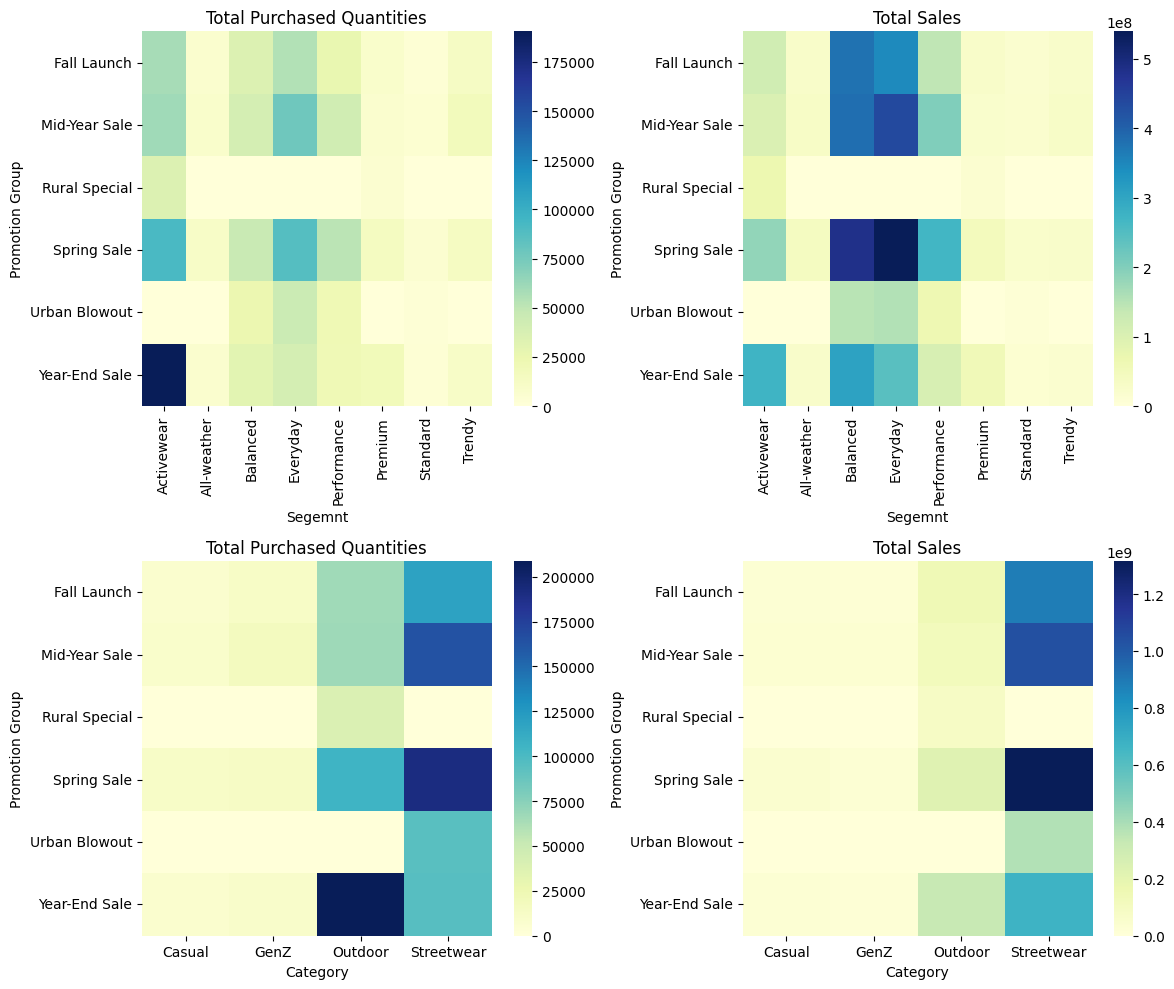

In [37]:
kwargs = {
    "cmap": 'YlGnBu',
    "xlabel": "Promotion Group"
}
fig = plt.figure(figsize=(12, 10))
axes = fig.subplots(2, 2)

sns.heatmap(gps["segment"]["num_items"], ax=axes[0, 0], cmap='YlGnBu')
sns.heatmap(gps["segment"]["total_sales"], ax=axes[0, 1], cmap='YlGnBu')

axes[0, 0].set_title("Total Purchased Quantities")
axes[0, 0].set_ylabel("Promotion Group")
axes[0, 0].set_xlabel("Segemnt")
axes[0, 1].set_title("Total Sales")
axes[0, 1].set_ylabel("Promotion Group")
axes[0, 1].set_xlabel("Segemnt")

sns.heatmap(gps["category"]["num_items"], ax=axes[1, 0], cmap='YlGnBu')
sns.heatmap(gps["category"]["total_sales"], ax=axes[1, 1], cmap='YlGnBu')

axes[1, 0].set_title("Total Purchased Quantities")
axes[1, 0].set_ylabel("Promotion Group")
axes[1, 0].set_xlabel("Category")
axes[1, 1].set_title("Total Sales")
axes[1, 1].set_ylabel("Promotion Group")
axes[1, 1].set_xlabel("Category")

fig.tight_layout();

In [ ]:
promo_group = "Spring Sale"

gps["customer"].reset_index()

,promotions.promo_group,customers.customer_id,total_orders,total_items,avg_items,total_sales,avg_sales,last_purchase
0,Year-End Sale,119892,9,58,4.833333,262622.28,21885.190000,2022-12-31
1,Year-End Sale,150387,6,36,6.000000,230078.29,38346.381667,2022-12-31
2,Year-End Sale,133692,7,40,5.714286,206555.77,29507.967143,2022-12-31
3,Year-End Sale,138626,6,52,6.500000,189415.54,23676.942500,2022-12-31
4,Year-End Sale,21510,4,25,6.250000,174284.94,43571.235000,2022-12-31
...,...,...,...,...,...,...,...,...
150899,Fall Launch,61114,1,3,3.000000,2903.25,2903.250000,2013-08-31
150900,Fall Launch,150486,1,1,1.000000,2067.14,2067.140000,2013-08-31
150901,Fall Launch,143000,1,1,1.000000,1755.44,1755.440000,2013-08-31
150902,Fall Launch,118303,1,1,1.000000,1351.06,1351.060000,2013-08-31


In [47]:
gps["customer"].loc["Spring Sale"]

,total_orders,total_items,avg_items,total_sales,avg_sales,last_purchase
customers.customer_id,,,,,,
157449,8,47,5.222222,243217.87,27024.207778,2022-04-17
132591,4,31,7.750000,239875.12,59968.780000,2022-04-17
23032,6,28,4.666667,234199.69,39033.281667,2022-04-17
128210,2,11,5.500000,148640.10,74320.050000,2022-04-17
132411,5,19,3.800000,126141.09,25228.218000,2022-04-17
...,...,...,...,...,...,...
139411,1,10,5.000000,6179.42,3089.710000,2013-03-18
34077,1,6,6.000000,5781.72,5781.720000,2013-03-18
155820,1,5,5.000000,4905.70,4905.700000,2013-03-18


In [38]:
dfs["products"].value_counts(["category", "segment"])

category    segment    
Outdoor     Activewear     566
Streetwear  Everyday       405
            Performance    347
            Balanced       306
            Standard       262
Outdoor     Premium        177
Casual      All-weather    169
GenZ        Trendy         148
Casual      Activewear      32
Name: count, dtype: int64

# RFM Analysis

In [5]:
def get_rfm(snapshot_dates: pd.Series):
    not_cancelled = full_order_items["orders.order_status"] != "cancelled"
    daily_df = full_order_items[not_cancelled].groupby(['orders.order_date', 'customers.customer_id', 'customers.signup_date']).agg(
        daily_spend=('sales_value', 'sum'),
        order_count=('orders.order_id', 'nunique'),
    ).reset_index()

    gp_obj = daily_df.groupby('customers.customer_id')
    daily_df['monetary'] = gp_obj['daily_spend'].cumsum()
    daily_df['frequency'] = gp_obj['order_count'].cumsum()
    daily_df.rename(columns={"orders.order_date": "last_purchase"}, inplace=True)
    daily_df.drop(columns=["daily_spend", "order_count"], inplace=True)
    
    rfm_history = pd.merge_asof(
        pd.MultiIndex.from_product(
            [daily_df["customers.customer_id"].unique(), snapshot_dates],
            names=['customers.customer_id', 'date']
        ).to_frame(index=False).sort_values("date"),
        daily_df, 
        left_on='date', 
        right_on='last_purchase', 
        by='customers.customer_id', 
        direction='backward'
    )

    rfm_history['recency'] = (rfm_history['date'] - rfm_history['last_purchase']).dt.days
    rfm_history['tenure'] = (rfm_history['date'] - rfm_history['customers.signup_date']).dt.days
    return rfm_history

In [6]:
dates = pd.Series([
    # pd.to_datetime("2022-04-01"),
    # pd.to_datetime("2022-07-01"),
    # pd.to_datetime("2022-10-01"),
    pd.to_datetime("2013-01-01"),
    pd.to_datetime("2014-01-01"),
    pd.to_datetime("2015-01-01"),
    pd.to_datetime("2016-01-01"),
    pd.to_datetime("2017-01-01"),
    pd.to_datetime("2018-01-01"),
    pd.to_datetime("2019-01-01"),
    pd.to_datetime("2020-01-01"),
    pd.to_datetime("2021-01-01"),
    pd.to_datetime("2022-01-01"),
    pd.to_datetime("2023-01-01")
])
rfm_df = get_rfm(dates)
rfm_df["frequency_bin"] = rfm_df["frequency"].map(
    lambda i: "[0, 10)" if i < 10 else
        "[10, 20)" if 10 <= i < 20 else
        "[20, 40)" if 20 <= i < 40 else
        ">=40"
)

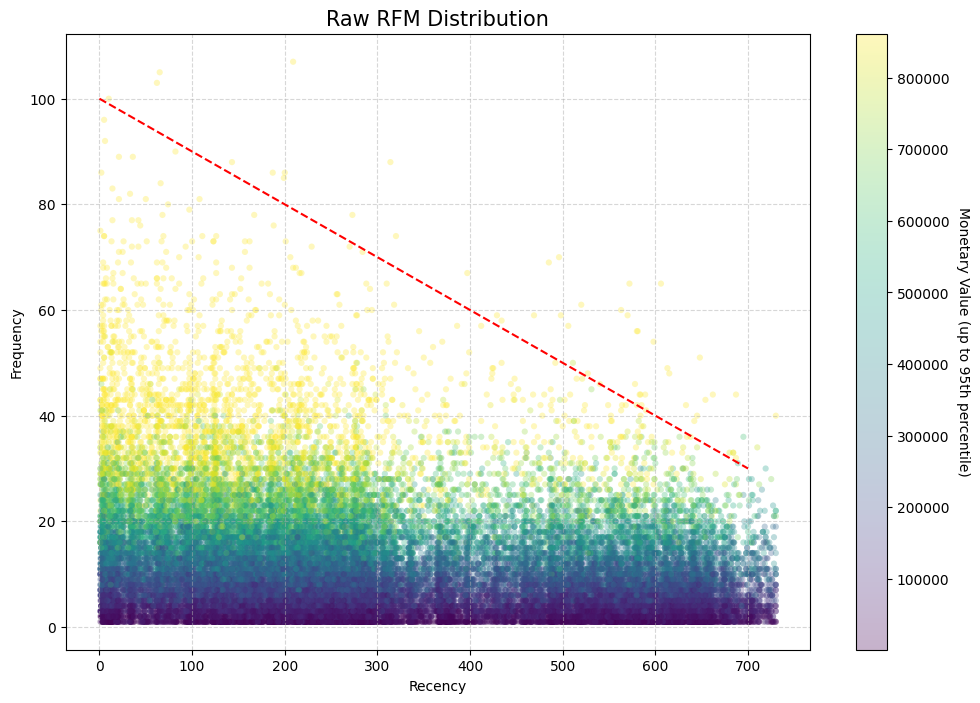

In [31]:
mask = (rfm_df["date"].dt.year == 2023) & (rfm_df["recency"] <= 730)
data = rfm_df[mask]

plt.figure(figsize=(12, 8))
norm = plt.Normalize(data['monetary'].min(), data['monetary'].quantile(0.95))

scatter = plt.scatter(
    x=data['recency'], 
    y=data['frequency'], 
    c=data['monetary'], 
    cmap='viridis',
    alpha=0.3,
    edgecolors='none', 
    s=20,
    norm=norm
)

# Adding a colorbar to explain the Monetary values
cbar = plt.colorbar(scatter)
cbar.set_label('Monetary Value (up to 95th percentile)', rotation=270, labelpad=15)
plt.plot([0, 700], [100, 30], "--", c="red")

plt.title('Raw RFM Distribution', fontsize=15)
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5);

In [7]:
quintiles = 5
labels = list(range(1, 6))
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], quintiles, labels=labels[::-1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), quintiles, labels=labels)
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], quintiles, labels=labels)

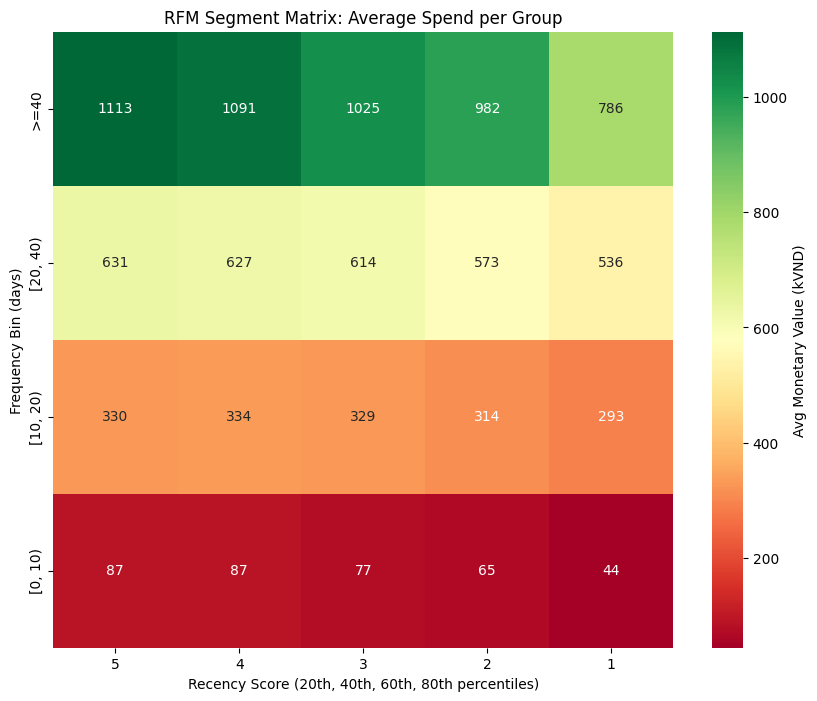

In [98]:
pivot = rfm_df.pivot_table(
    index='frequency_bin', 
    columns='R_score', 
    values='monetary', 
    aggfunc='mean'
) / 1e3
pivot = pivot.loc[["[0, 10)", "[10, 20)", "[20, 40)", ">=40"]]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", cbar_kws={'label': 'Avg Monetary Value (kVND)'})

plt.title('RFM Segment Matrix: Average Spend per Group')
plt.xlabel('Recency Score (20th, 40th, 60th, 80th percentiles)')
plt.ylabel('Frequency Bin (days)')
plt.gca().invert_yaxis()
plt.show()

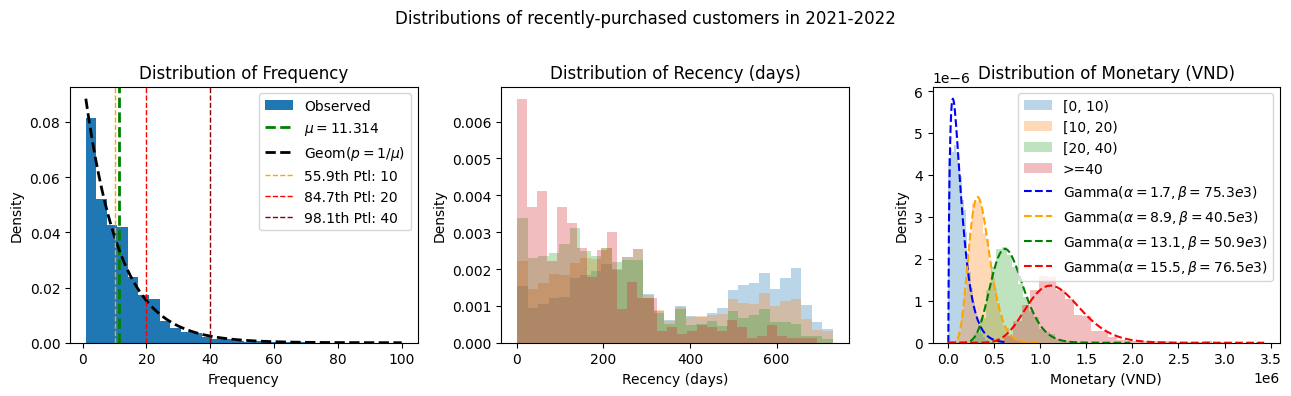

In [13]:
fig = plt.figure(figsize=(13, 4))
axes = fig.subplots(1, 3)

# samples = rfm_df
samples = rfm_df[(rfm_df["recency"] <= 730) & (rfm_df["date"].dt.year == 2023)]
samples["frequency"].plot.hist(
    xlabel="Frequency",
    ylabel="Density",
    label="Observed",
    ax=axes[0],
    bins=30,
    density=True
)

mu = samples["frequency"].mean()
axes[0].axvline(mu, color="green", linestyle='--', linewidth=2, label=rf'$\mu={mu:.3f}$')

x_range = np.arange(1, samples["frequency"].max() + 1)
axes[0].plot(
    x_range,
    (1 - 1 / mu) ** (x_range - 1) * 1 / mu,
    color='black',
    linestyle='--',
    lw=2, label=r"Geom($p=1/\mu$)"
)

for t, color in zip([10, 20, 40], ['orange', 'red', 'darkred']):
    p_rank = stats.percentileofscore(samples["frequency"], t)
    axes[0].axvline(t, color=color, linestyle='--', linewidth=1, label=f'{p_rank:.1f}th Ptl: {t}')
axes[0].legend()
axes[0].set_title("Distribution of Frequency")

groups = ["[0, 10)", "[10, 20)", "[20, 40)", ">=40"], ["blue", "orange", "green", "red"]
for i, (cate, name) in enumerate(zip(["recency", "monetary"], ["Recency (days)", "Monetary (VND)"])):
    ax = axes[i+1]
    for i, c in zip(*groups):
        filtered = samples.loc[samples["frequency_bin"] == i, cate]
        filtered.plot.hist(
            bins=30,
            xlabel=name,
            ylabel="Density",
            label=i,
            density=True,
            alpha=0.3,
            ax=ax
        )
        ax.set_title(f"Distribution of {name}")

    if cate != "monetary": continue
    for i, c in zip(*groups):
        filtered = samples.loc[samples["frequency_bin"] == i, [cate, "frequency"]]
        x = np.linspace(0, filtered["monetary"].max(), 100)
        alpha, loc, beta = stats.gamma.fit(filtered["monetary"], floc=0)
        y = stats.gamma.pdf(x, [alpha], scale=beta, loc=loc)
        ax.plot(
            x, y, color=c, linestyle="--",
            label=rf'Gamma($\alpha={alpha:.1f}, \beta={beta / 1e3:.1f}e3$)'
        )
    ax.legend()
fig.suptitle("Distributions of recently-purchased customers in 2021-2022")
fig.tight_layout()

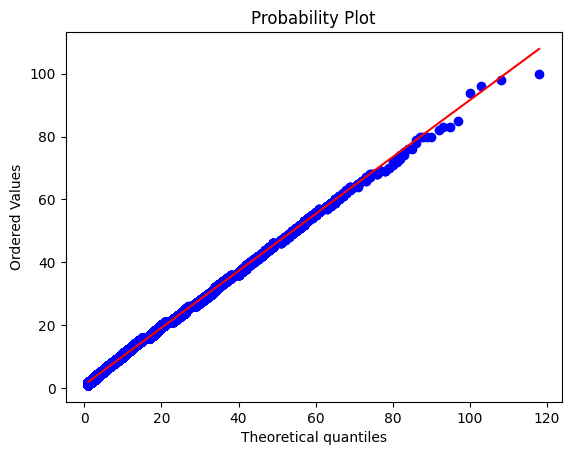

In [ ]:
_, (w, b, R2) = stats.probplot(samples["frequency"], (1/mu,), stats.geom, plot=plt)

# Viz

## Products - Orders

In [ ]:
not_returned = ~full_order_items["orders.order_id"].isin(full_returns["orders.order_id"])

non_returned_df = full_order_items[not_returned]
non_returned_df["total"] = non_returned_df["order_items.unit_price"] * non_returned_df["order_items.quantity"]

In [28]:
def compare_profit_sold(
    group_by,
    top_k=10,
    *,
    xlabel=None,
    rot=None,
):
    if top_k is None or top_k > len(group_by):
        top_k = len(group_by)

    fig = plt.figure(figsize=(15, 5))
    axes = fig.subplots(1, 2)

    sort_revenue = group_by.sort_values(["total_revenue", "total_sold"], ascending=False).iloc[:top_k]
    sort_revenue.plot.bar(y="total_sold", ax=axes[0], ylabel="Items sold")
    sort_revenue.plot.line(
        y="total_revenue",
        secondary_y=True,
        rot=rot,
        color="orange",
        linestyle="none",
        marker="o",
        xlabel=xlabel,
        title=f"Top {top_k} most profitable products",
        ax=axes[0]
    )

    sort_sold = group_by.sort_values(["total_sold", "total_revenue"], ascending=False).iloc[:top_k]
    sort_sold.plot.bar(y="total_sold", ax=axes[1])
    sort_sold.plot.line(
        y="total_revenue",
        secondary_y=True,
        rot=rot,
        color="orange",
        linestyle="none",
        marker="o",
        xlabel=xlabel,
        ylabel="VND",
        title=f"Top {top_k} most sold products",
        ax=axes[1],
    )
    return fig

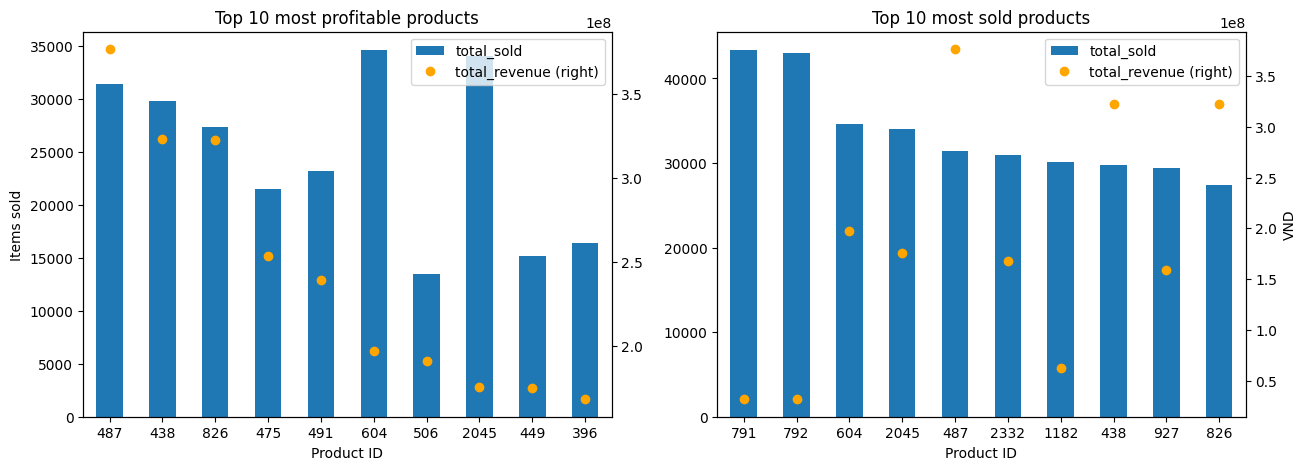

In [ ]:
gp_product = non_returned_df.groupby(["products.product_id", "products.product_name"]).agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
).reset_index(1)
gp_product.index = gp_product.index.map(str)
compare_profit_sold(gp_product, xlabel="Product ID");

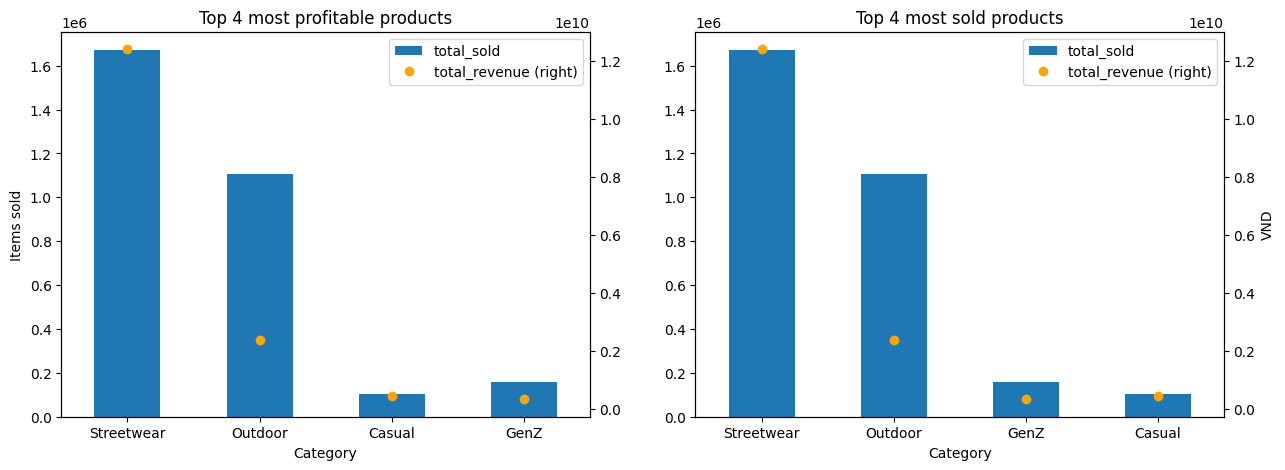

In [30]:
gp_cat = non_returned_df.groupby("products.category").agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
)
compare_profit_sold(gp_cat, xlabel="Category");

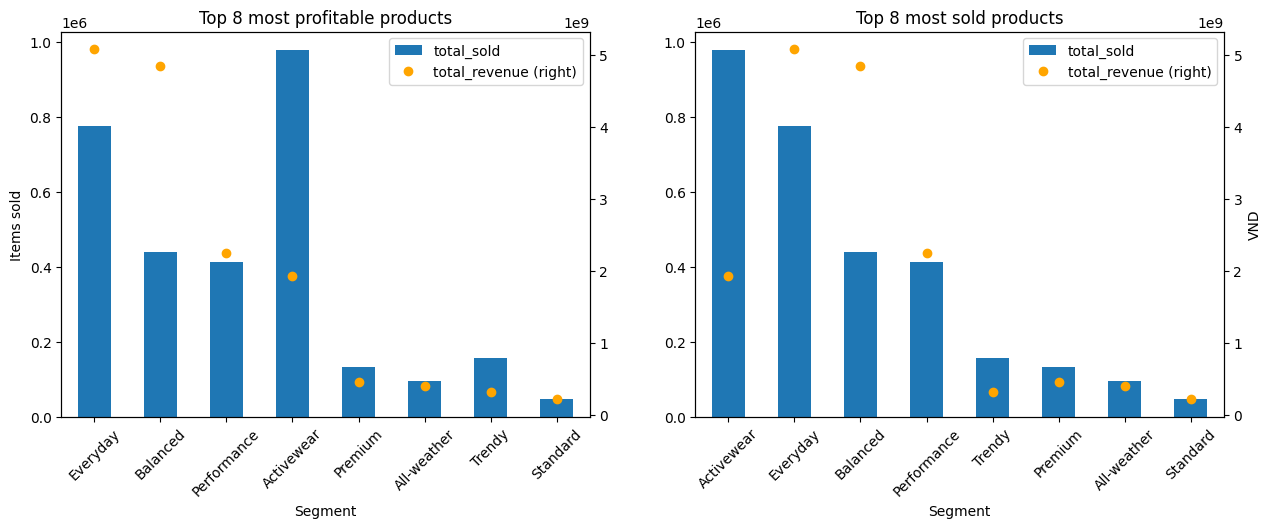

In [31]:
gp_seg = non_returned_df.groupby("products.segment").agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
)
compare_profit_sold(gp_seg, xlabel="Segment", rot=45);

## Promotions

In [ ]:
promtions = dfs["promotions"]
promtions["start_month"] = promtions["start_date"].dt.month
promtions["end_month"] = promtions["end_date"].dt.month
promtions["start_day"] = promtions["start_date"].dt.day
promtions["end_day"] = promtions["end_date"].dt.day

In [ ]:
promtions.groupby(["promo_id"]).agg(
    start_day=("start_day", "unique"),
    end_day=("end_day", "unique"),
    start_month=("start_month", "unique"),
    end_month=("end_month", "unique"),
    name=("promo_name", 'unique')
)

## Products - Reviews

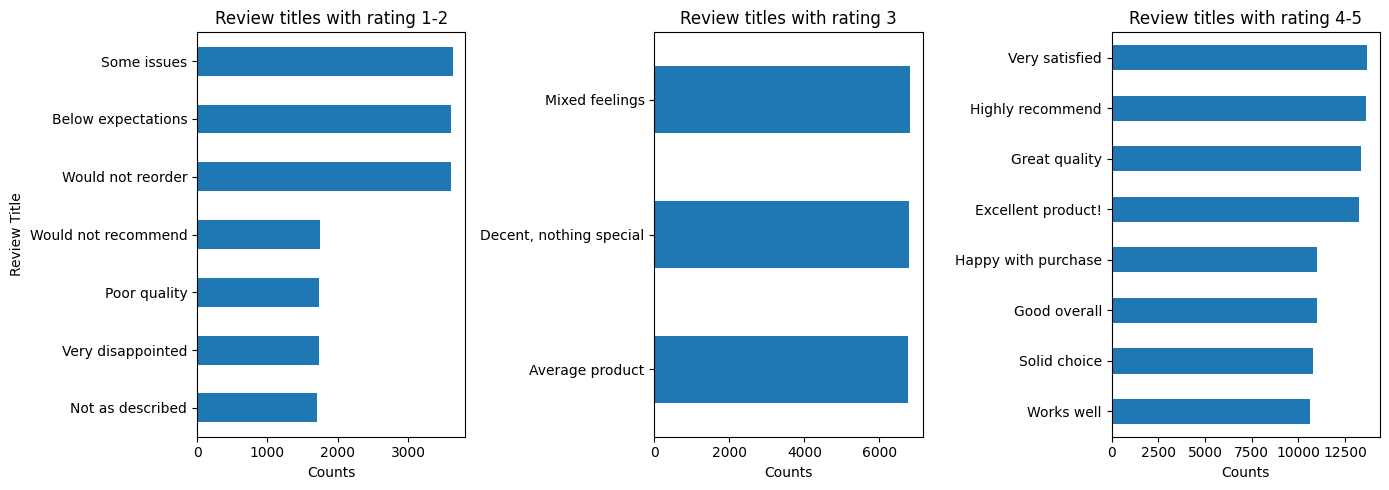

In [54]:
fig = plt.figure(figsize=(14, 5))
axes = fig.subplots(1, 3)

full_reviews["rating_bin"] = full_reviews["reviews.rating"].apply(lambda i: 0 if 1 <= i <= 2 else 1 if i == 3 else 2)
rating_groups = ["1-2", "3", "4-5"]
for rating_bin, rows in full_reviews.groupby("rating_bin"):
    rows.value_counts("reviews.review_title", ascending=True).plot.barh(
        xlabel="Counts",
        ylabel="",
        title=f"Review titles with rating {rating_groups[rating_bin]}",
        ax=axes[rating_bin]
    )

axes[0].set_ylabel("Review Title")
fig.tight_layout();

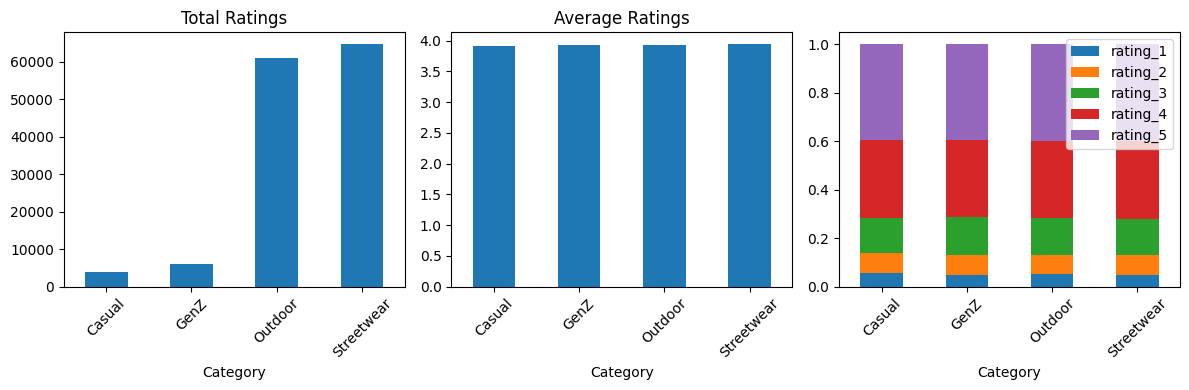

In [99]:
gp_category = full_reviews.groupby("products.category").agg(
    num_ratings=("reviews.review_id", "count"),
    avg_ratings=("reviews.rating", "mean"),
    rating_1=("reviews.rating", lambda row: (row == 1).sum() / len(row)),
    rating_2=("reviews.rating", lambda row: (row == 2).sum() / len(row)),
    rating_3=("reviews.rating", lambda row: (row == 3).sum() / len(row)),
    rating_4=("reviews.rating", lambda row: (row == 4).sum() / len(row)),
    rating_5=("reviews.rating", lambda row: (row == 5).sum() / len(row)),
)

fig = plt.figure(figsize=(12, 4))
axes = fig.subplots(1, 3)

gp_category.plot.bar(
    y="num_ratings",
    xlabel="Category",
    rot=45,
    ax=axes[0],
    title="Total Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y="avg_ratings",
    xlabel="Category",
    rot=45,
    ax=axes[1],
    title="Average Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y=[f"rating_{i}" for i in range(1, 6)],
    xlabel="Category",
    stacked=True,
    rot=45,
    ax=axes[2]
)
fig.tight_layout();

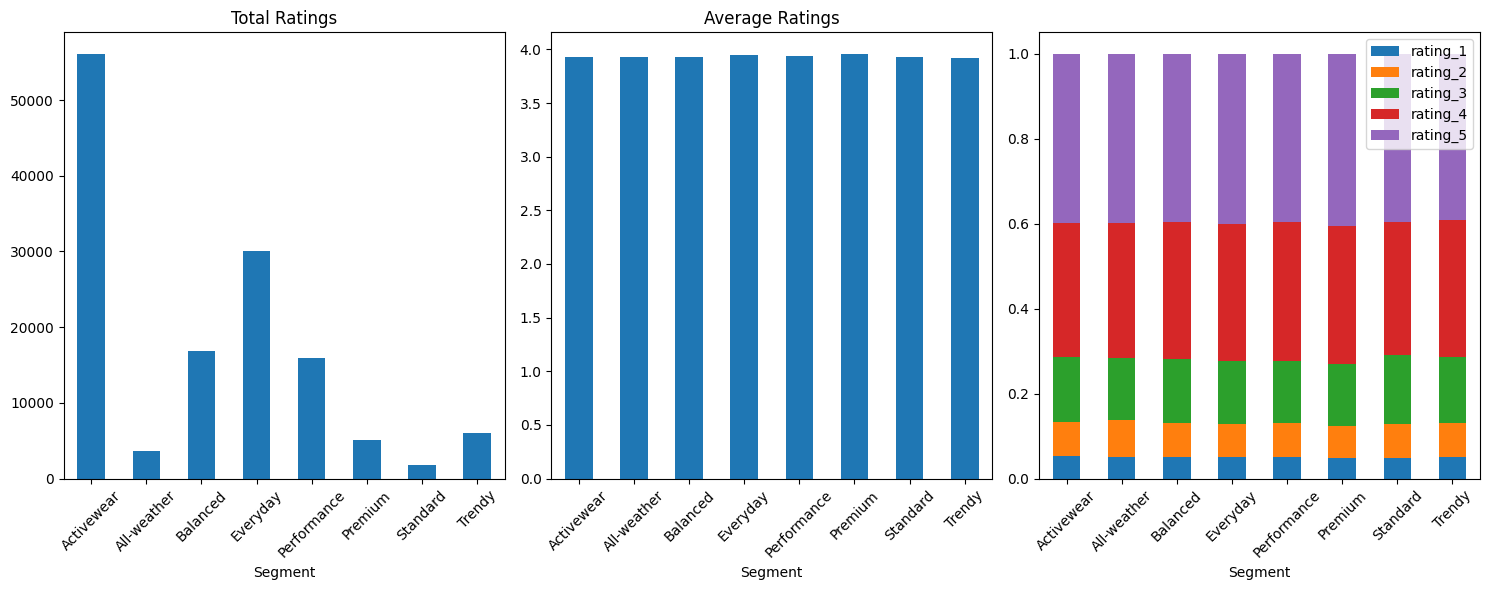

In [98]:
gp_category = full_reviews.groupby("products.segment").agg(
    num_ratings=("reviews.review_id", "count"),
    avg_ratings=("reviews.rating", "mean"),
    rating_1=("reviews.rating", lambda row: (row == 1).sum() / len(row)),
    rating_2=("reviews.rating", lambda row: (row == 2).sum() / len(row)),
    rating_3=("reviews.rating", lambda row: (row == 3).sum() / len(row)),
    rating_4=("reviews.rating", lambda row: (row == 4).sum() / len(row)),
    rating_5=("reviews.rating", lambda row: (row == 5).sum() / len(row)),
)

fig = plt.figure(figsize=(15, 6))
axes = fig.subplots(1, 3)

gp_category.plot.bar(
    y="num_ratings",
    xlabel="Segment",
    rot=45,
    ax=axes[0],
    title="Total Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y="avg_ratings",
    xlabel="Segment",
    rot=45,
    ax=axes[1],
    title="Average Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y=[f"rating_{i}" for i in range(1, 6)],
    xlabel="Segment",
    stacked=True,
    rot=45,
    ax=axes[2]
)
fig.tight_layout();

## Customer

In [ ]:
customer_gp = non_returned_df.groupby("customers.customer_id").agg(
    num_orders=("orders.order_id", "nunique"),
    unique_products=("products.product_id", "nunique"),
    num_items=("order_items.quantity", "sum"),
)
return_gp = full_returns.groupby("customers.customer_id").agg(
    num_returns=("orders.order_id", "nunique"),
    unique_return_products=("products.product_id", "nunique"),
    num_return_items=("returns.return_quantity", "sum"),
    most_returned=("products.product_id", pd.Series.mode)
)

customer_gp = customer_gp.merge(return_gp, "left", left_index=True, right_index=True)

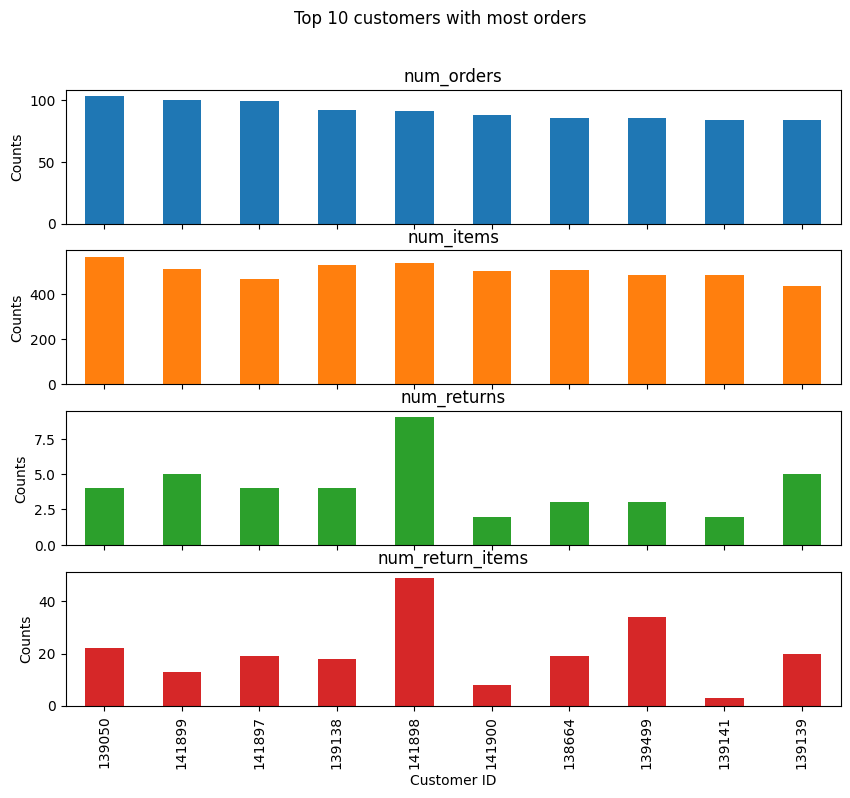

In [ ]:
top_k = 10

customer_gp.sort_values(["num_orders", "num_items", "num_returns"], inplace=True, ascending=False)
customer_gp.iloc[:top_k].plot.bar(
    y=["num_orders", "num_items", "num_returns", "num_return_items"],
    ylabel="Counts",
    xlabel="Customer ID",
    title="Top 10 customers with most orders",
    subplots=True,
    legend=False,
    figsize=(10, 8),
);

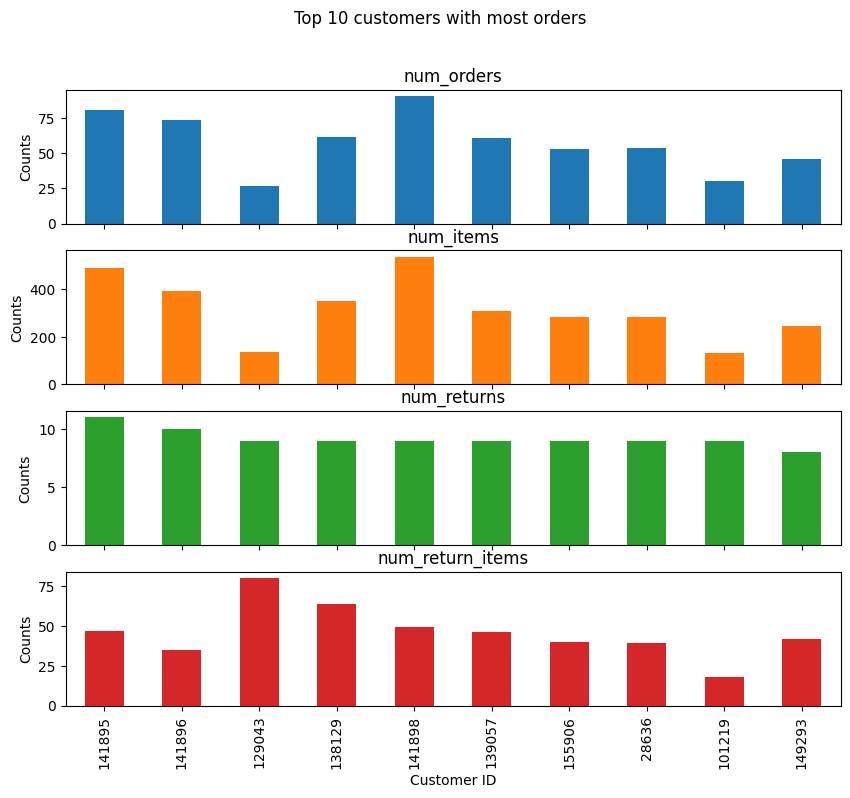

In [111]:
top_k = 10

customer_gp.sort_values(["num_returns", "num_return_items", "num_orders"], inplace=True, ascending=False)
customer_gp.iloc[:top_k].plot.bar(
    y=["num_orders", "num_items", "num_returns", "num_return_items"],
    ylabel="Counts",
    xlabel="Customer ID",
    title="Top 10 customers with most orders",
    subplots=True,
    legend=False,
    figsize=(10, 8),
);